<a href="https://colab.research.google.com/github/ThienPhu2708/2001230673_PhungDuongThienPhu_THDeepLearning_Buoi2/blob/main/2001230673_PhungDuongThienPhu_TH_DeepLearning_Buoi03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Viết chương trình cài đặt ANN để nhận dạng ảnh trên bộ dataset CIFAR10 có sẵn trong tensorflow
với các nhãn sau.


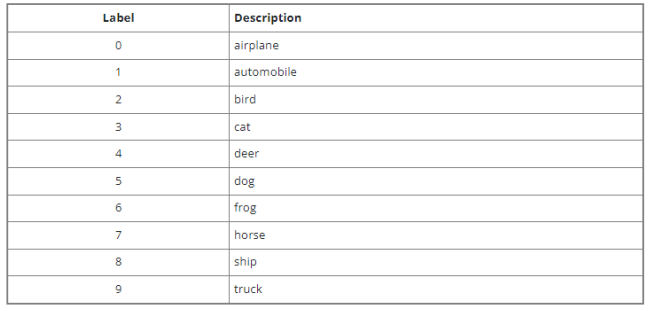

In [ ]:
#Step1
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense,Dropout
from sklearn.preprocessing import MinMaxScaler


#Step2: Doc du lieu
cifar = tf.keras.datasets.cifar10
(X_train, y_train), (X_test, y_test) = cifar.load_data()
print(X_train.shape, y_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
(50000, 32, 32, 3) (50000, 1)


In [ ]:
#Step3: Xu ly du lieu, Flatten 32*32*3 = 3072
X_train = X_train.reshape(50000, 3072)
X_test = X_test.reshape(10000, 3072)

#[0,1]
minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

y_train = y_train.flatten()  # CIFAR có shape (50000,1) cần làm phẳng
y_test = y_test.flatten()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

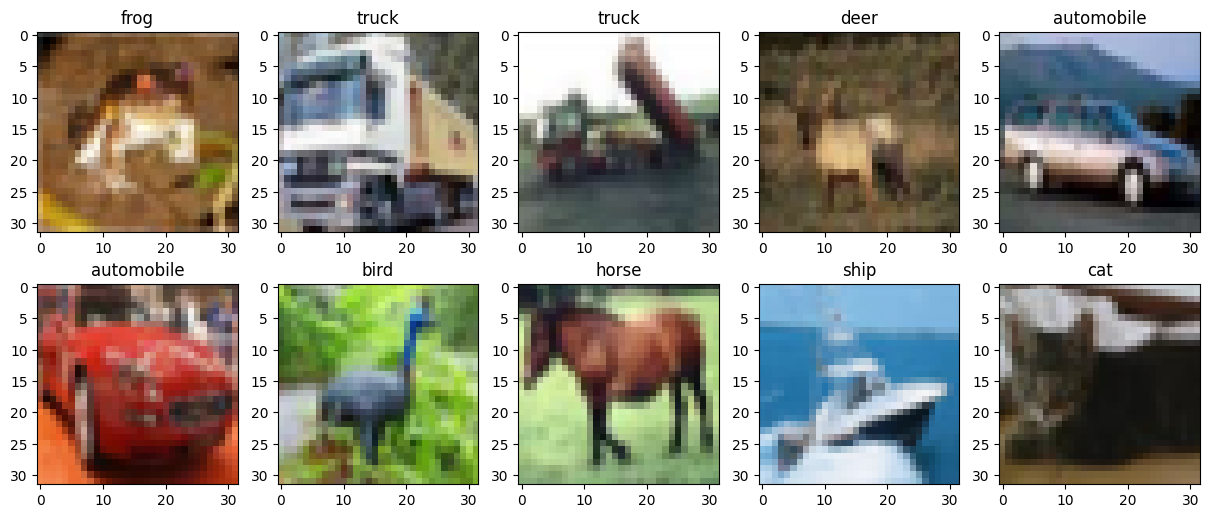

In [ ]:
# Bước 4: Trực quan hóa
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(32, 32, 3))
    ax[i].set_title(class_names[y_train[i]])
plt.show()

In [ ]:
# Bước 5: Xây mô hình
# CIFAR-10 khó hơn MNIST nhiều, cần mạng sâu hơn + dropout
model = Sequential()
model.add(Dense(input_dim=3072, units=512, kernel_initializer='uniform', activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(units=256, kernel_initializer='uniform', activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Bước 6: Huấn luyện
history = model.fit(X_train, y_train, validation_split=0.1, epochs=30, verbose=1)

Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.2738 - loss: 1.9698 - val_accuracy: 0.3280 - val_loss: 1.8443
Epoch 2/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.3216 - loss: 1.8646 - val_accuracy: 0.3408 - val_loss: 1.8312
Epoch 3/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.3358 - loss: 1.8253 - val_accuracy: 0.3766 - val_loss: 1.7622
Epoch 4/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.3495 - loss: 1.7918 - val_accuracy: 0.3820 - val_loss: 1.7500
Epoch 5/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.3610 - loss: 1.7691 - val_accuracy: 0.3910 - val_loss: 1.7109
Epoch 6/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.3651 - loss: 1.7492 - val_accuracy: 0.4024 - val_loss: 1.6654
Epoch 7/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.3691 - loss: 1.7327 - val_accuracy: 0.4198 - val_loss: 1.6445
Epoch 8/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.3752 -

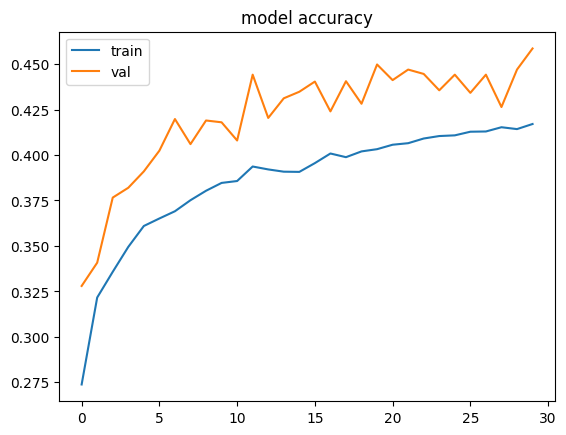

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0925 - loss: 2.3053
Test accuracy: 0.0925


In [ ]:
# Bước 7: Đánh giá
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy'); plt.legend(['train','val'])
plt.show()

test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_acc:.4f}')

In [ ]:
# Bước 8: Dự báo
pred = model.predict(X_test[:10])
for i in range(10):
    print(f'Predicted: {class_names[np.argmax(pred[i])]}, True: {class_names[y_test[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted: airplane, True: cat
Predicted: airplane, True: ship
Predicted: airplane, True: ship
Predicted: airplane, True: airplane
Predicted: automobile, True: frog
Predicted: automobile, True: frog
Predicted: automobile, True: automobile
Predicted: automobile, True: frog
Predicted: automobile, True: cat
Predicted: automobile, True: automobile


2. Viết chương trình cài đặt ANN để nhận dạng ảnh chữ viết số trên bộ dataset MNIST do giảng viên cung cấp với các nhãn sau.

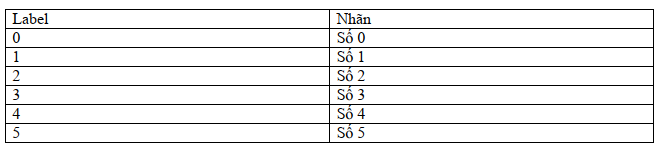
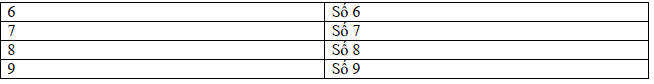

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler

# Đọc dữ liệu
mnist = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Reshape + scale
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

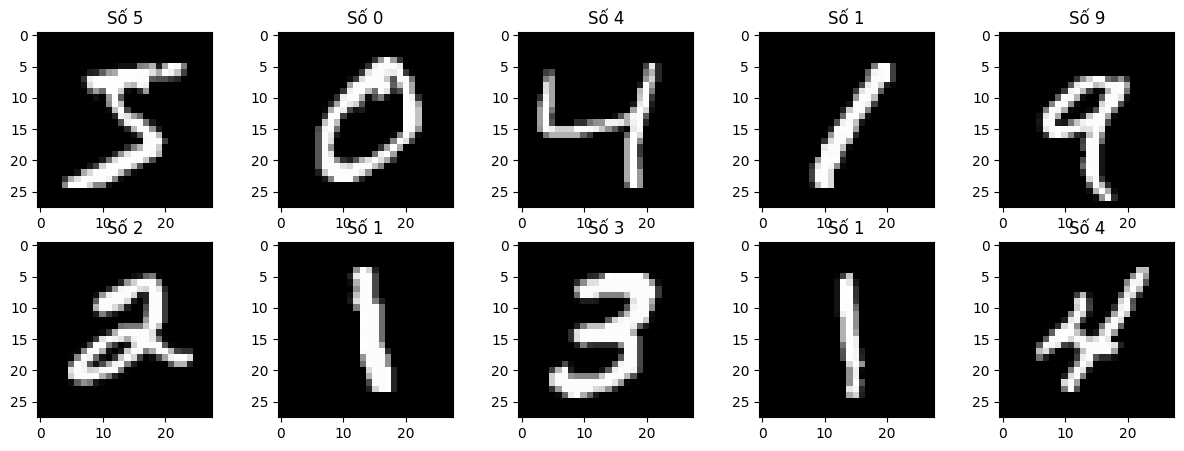

In [ ]:
# Trực quan hóa
fig, axes = plt.subplots(2, 5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax[i].set_title(f'Số {y_train[i]}')
plt.show()

In [ ]:
# Xây mô hình
model = Sequential()
model.add(Dense(input_dim=784, units=256, kernel_initializer='uniform', activation='relu'))
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
#Train
history = model.fit(X_train, y_train, validation_split=0.1, epochs=20, verbose=1)


Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9232 - loss: 0.2680 - val_accuracy: 0.9707 - val_loss: 0.1059
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9682 - loss: 0.1068 - val_accuracy: 0.9747 - val_loss: 0.0898
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9785 - loss: 0.0709 - val_accuracy: 0.9788 - val_loss: 0.0724
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9842 - loss: 0.0503 - val_accuracy: 0.9767 - val_loss: 0.0774
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9884 - loss: 0.0373 - val_accuracy: 0.9808 - val_loss: 0.0693
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9911 - loss: 0.0288 - val_accuracy: 0.9792 - val_loss: 0.0768
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9938 - loss: 0.0205 - val_accuracy: 0.9818 - val_loss: 0.0715
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9940 - loss: 0.0181 - 

In [ ]:
# Đánh giá
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_acc:.4f}')  # ~98%

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9795 - loss: 0.1159
Test accuracy: 0.9795


In [ ]:
# Dự báo
print(np.argmax(model.predict(X_test)[0]), y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
7 7
